Entity counts for Synthetic dataset:
Counter({'I-FaultType': 12321, 'I-DeviceProperties': 6757, 'I-CustomerReportedSymptom': 3706, 'I-VehicleComponentLocation': 2921, 'B-MaintenanceMethod': 2000, 'B-FaultCode': 2000, 'B-FaultType': 2000, 'B-VehicleComponentLocation': 2000, 'B-CustomerReportedSymptom': 2000, 'B-MeasurementValue': 2000, 'B-TimeDuration': 2000, 'I-TimeDuration': 2000, 'B-VehicleMakeModel': 2000, 'B-DeviceProperties': 2000, 'B-EquipmentName': 1996, 'I-MeasurementValue': 1847, 'I-EquipmentName': 1310})



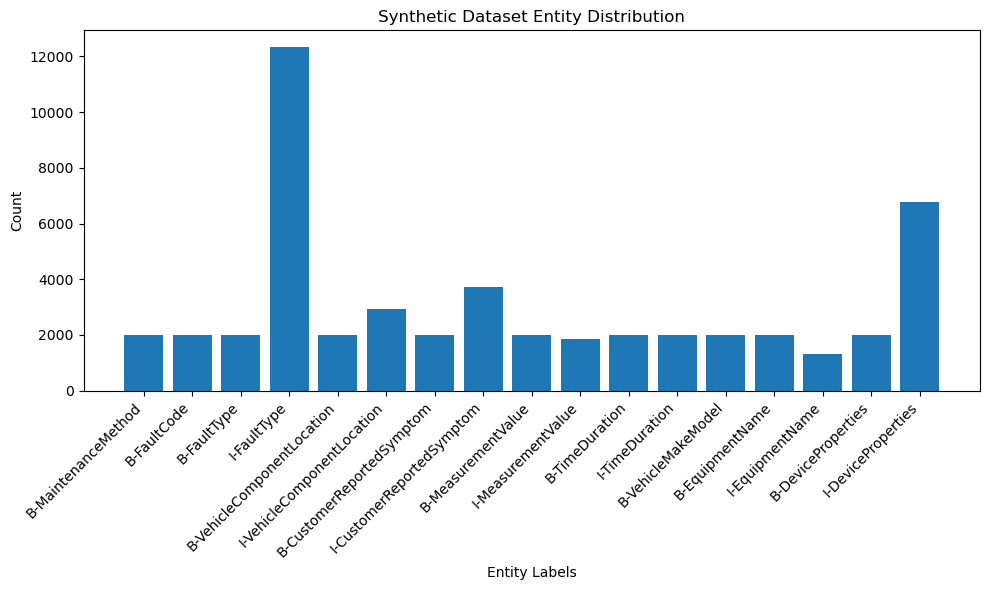

Entity counts for Adversarial dataset:
Counter({'I-CustomerReportedSymptom': 582, 'B-FaultType': 540, 'B-VehicleMakeModel': 535, 'I-VehicleMakeModel': 535, 'B-CustomerReportedSymptom': 479, 'I-FaultType': 389, 'B-FaultCode': 349, 'B-TimeDuration': 310, 'B-MeasurementValue': 304, 'B-EquipmentName': 288, 'I-TimeDuration': 287, 'B-VehicleComponentLocation': 282, 'B-DeviceProperties': 250, 'I-DeviceProperties': 250, 'B-MaintenanceMethod': 247, 'I-MaintenanceMethod': 247, 'I-VehicleComponentLocation': 246, 'I-EquipmentName': 216, 'I-MeasurementValue': 147})



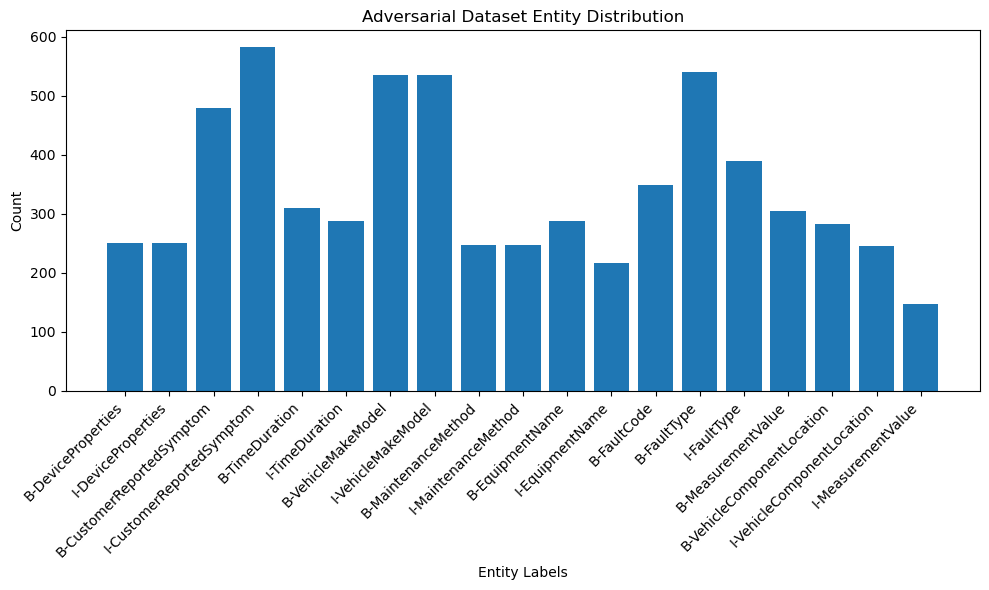

Entity counts for In-house dataset:
Counter({'I-CustomerReportedSymptom': 196, 'B-EquipmentName': 133, 'I-MaintenanceMethod': 111, 'I-EquipmentName': 104, 'I-DeviceProperties': 71, 'B-MaintenanceMethod': 70, 'B-CustomerReportedSymptom': 40, 'B-DeviceProperties': 36, 'I-TimeDuration': 31, 'I-MeasurementValue': 30, 'I-VehicleComponentLocation': 30, 'I-FaultType': 28, 'B-MeasurementValue': 27, 'B-FaultType': 22, 'B-FaultCode': 18, 'B-VehicleComponentLocation': 18, 'I-FaultCode': 8, 'B-TimeDuration': 8, 'B-VehicleMakeModel': 2})



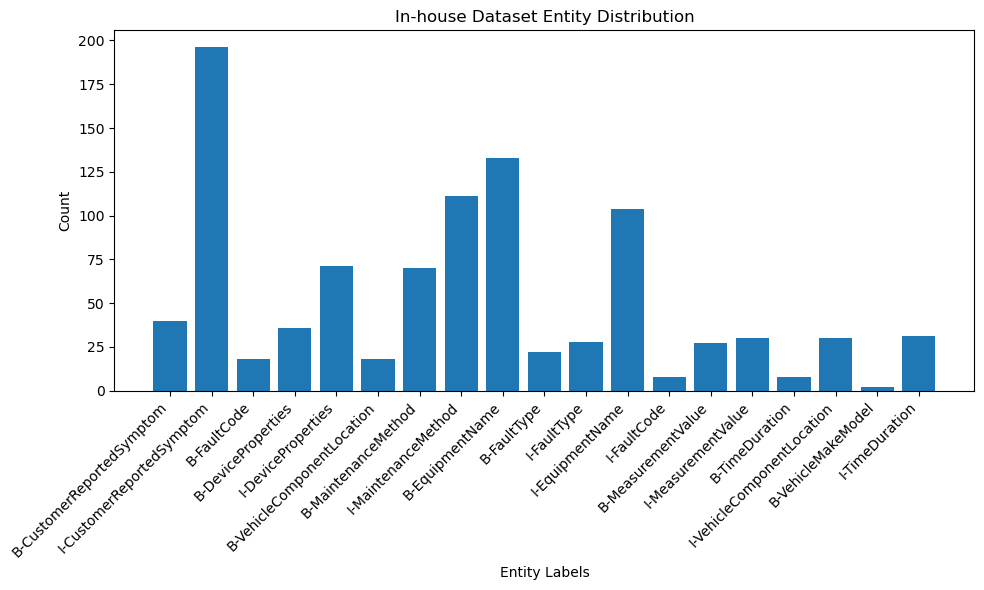

In [2]:
import os
from collections import Counter
import matplotlib.pyplot as plt

def get_entity_counts(conll_file):
    """
    Reads a CoNLL file and counts entity labels.
    Assumes file format: token <space> label
    """
    counts = Counter()
    with open(conll_file, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:  # sentence separator
                continue
            parts = line.split()
            if len(parts) < 2:
                continue
            label = parts[-1]  # last column is label
            if label != "O":
                counts[label] += 1
    return counts

def plot_entity_distribution(counts, title, save_path=None):
    """
    Plots entity distribution as a bar chart.
    """
    labels, values = zip(*counts.items())
    plt.figure(figsize=(10, 6))
    plt.bar(labels, values)
    plt.xticks(rotation=45, ha="right")
    plt.xlabel("Entity Labels")
    plt.ylabel("Count")
    plt.title(title)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300)
    plt.show()

# Example usage with three datasets
datasets = {
    "Synthetic": "synthetic_test_v1.conll",
    "Adversarial": "advarsarial.conll",
    "In-house": "goldset.conll"
}

for name, file in datasets.items():
    if os.path.exists(file):
        counts = get_entity_counts(file)
        print(f"Entity counts for {name} dataset:\n{counts}\n")
        plot_entity_distribution(counts, f"{name} Dataset Entity Distribution",
                                 save_path=f"{name.lower()}_distribution.png")
    else:
        print(f"⚠️ File not found: {file}")


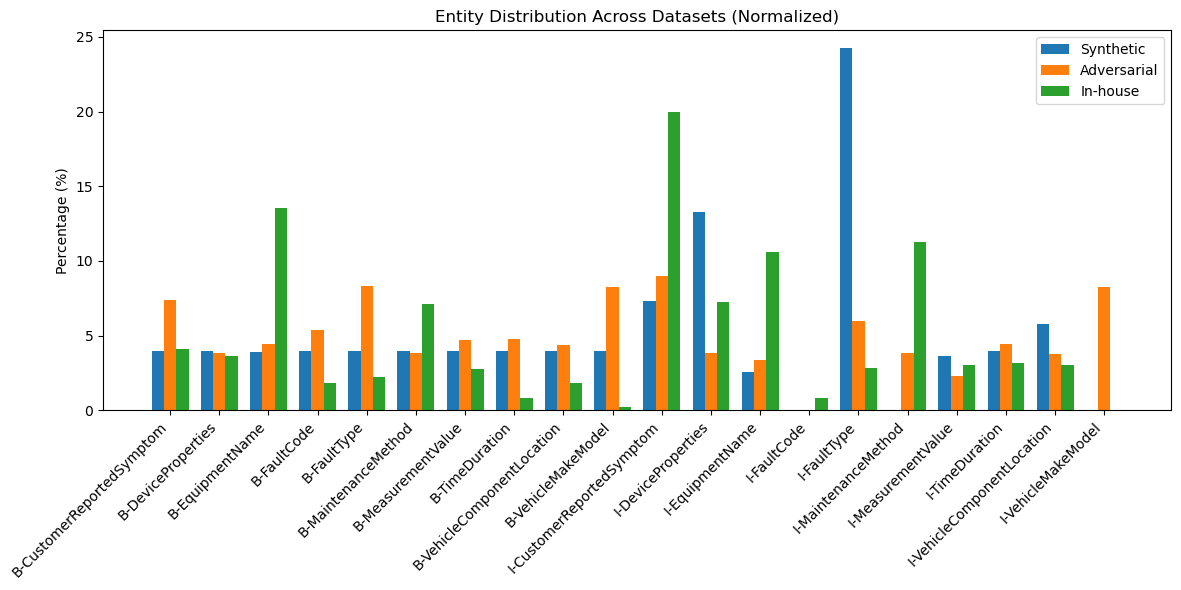

In [6]:
import os
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np

def get_entity_counts(conll_file):
    """
    Reads a CoNLL file and counts entity labels.
    Assumes file format: token <space> label
    """
    counts = Counter()
    with open(conll_file, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:  # sentence separator
                continue
            parts = line.split()
            if len(parts) < 2:
                continue
            label = parts[-1]  # last column is label
            if label != "O":
                counts[label] += 1
    return counts


datasets = {
    "Synthetic": "synthetic_test_v1.conll",
    "Adversarial": "advarsarial.conll",
    "In-house": "goldset.conll"
}

# Collect counts
all_counts = {}
all_entities = set()

for name, file in datasets.items():
    if os.path.exists(file):
        counts = get_entity_counts(file)
        total = sum(counts.values())
        # Convert to percentages
        percentages = {k: (v / total) * 100 for k, v in counts.items()}
        all_counts[name] = percentages
        all_entities.update(percentages.keys())
    else:
        print(f"⚠️ File not found: {file}")

# Ensure consistent ordering of entities
all_entities = sorted(all_entities)

# Create grouped bar plot (percentages)
x = np.arange(len(all_entities))  # label positions
width = 0.25  # width of each bar
colors = ["tab:blue", "tab:orange", "tab:green"]

plt.figure(figsize=(12, 6))

for i, (name, counts) in enumerate(all_counts.items()):
    values = [counts.get(ent, 0) for ent in all_entities]
    plt.bar(x + i*width, values, width, label=name, color=colors[i])

plt.xticks(x + width, all_entities, rotation=45, ha="right")
plt.ylabel("Percentage (%)")
plt.title("Entity Distribution Across Datasets (Normalized)")
plt.legend()
plt.tight_layout()
plt.savefig("entity_distribution_normalized.png", dpi=300)
plt.show()


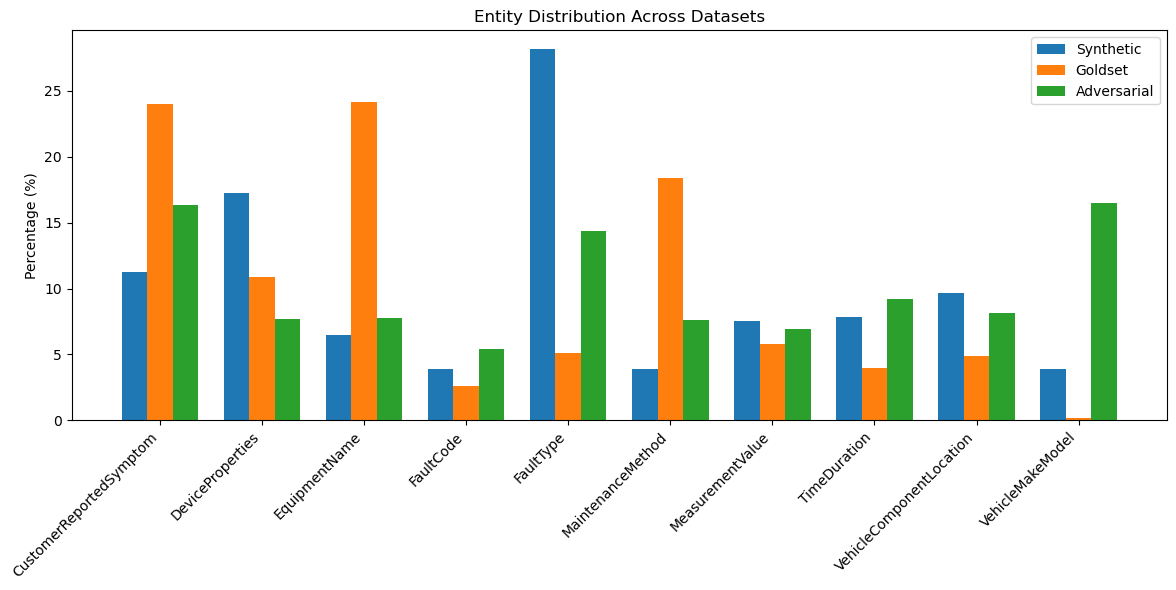

In [9]:
import os
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
import numpy as np

def get_entity_counts_combined(conll_file):
    """
    Reads a CoNLL file and counts entity labels, combining B- and I- prefixes.
    """
    counts = Counter()
    with open(conll_file, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:  # sentence separator
                continue
            parts = line.split()
            if len(parts) < 2:
                continue
            label = parts[-1]  # last column is label
            if label != "O":
                # Remove B- or I- prefix
                entity = label[2:] if label.startswith(("B-", "I-")) else label
                counts[entity] += 1
    return counts

datasets = {
    "Synthetic": "synthetic_test_v1.conll",
    "Goldset": "goldset.conll",
    "Adversarial": "advarsarial.conll"
}

# Collect counts
all_counts = {}
all_entities = set()

for name, file in datasets.items():
    if os.path.exists(file):
        counts = get_entity_counts_combined(file)
        total = sum(counts.values())
        # Convert to percentages
        percentages = {k: (v / total) * 100 for k, v in counts.items()}
        all_counts[name] = percentages
        all_entities.update(percentages.keys())
    else:
        print(f"⚠️ File not found: {file}")

# Ensure consistent ordering of entities
all_entities = sorted(all_entities)

# Create grouped bar plot (percentages)
x = np.arange(len(all_entities))  # label positions
width = 0.25  # width of each bar
colors = ["tab:blue", "tab:orange", "tab:green"]

plt.figure(figsize=(12, 6))

for i, (name, counts) in enumerate(all_counts.items()):
    values = [counts.get(ent, 0) for ent in all_entities]
    plt.bar(x + i*width, values, width, label=name, color=colors[i])

plt.xticks(x + width, all_entities, rotation=45, ha="right")
plt.ylabel("Percentage (%)")
plt.title("Entity Distribution Across Datasets")
plt.legend()
plt.tight_layout()
plt.savefig("entity_distribution_normalized_combined.png", dpi=300)
plt.show()
